# EDA — Intersection-Level Traffic Calming Devices

Este notebook analiza el dataset de dispositivos de calmado de tráfico instalados a nivel de intersección. Además, investiga cómo unirlo con los datasets de accidentes con lesiones, accidentes fatales, PCI histórico y medidas mid-block.

**Idea clave:** este dataset está a nivel de **intersección**, por lo que su clave natural es `cnn`, que debe cruzarse principalmente con `cnn_intrsctn_fkey` en accidentes con lesiones. No debe confundirse con `cnn_sgmt_fkey`, que representa segmentos.

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

CANDIDATE_DIRS = [Path.cwd(), Path.cwd().parent, Path("/mnt/data")]

def resolve_file(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"No encontré {filename}. Colócalo en la misma carpeta del notebook o en /mnt/data.")

def read_csv_resolved(filename: str, **kwargs) -> pd.DataFrame:
    path = resolve_file(filename)
    print(f"Leyendo: {path}")
    return pd.read_csv(path, low_memory=False, **kwargs)

NULL_TOKENS = ["<Null>", "NULL", "Null", "null", "None", ""]

def normalize_nulls(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.replace(NULL_TOKENS, np.nan)
    return out

def to_int_key(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicated_rows": [df.duplicated().sum()],
        "memory_mb": [round(df.memory_usage(deep=True).sum() / 1024**2, 2)]
    })

def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "nunique": df.nunique(dropna=True).values,
    })
    return rep.sort_values(["missing_pct", "missing"], ascending=False).reset_index(drop=True)

def top_values(df: pd.DataFrame, col: str, n: int = 15) -> pd.DataFrame:
    s = df[col]
    out = s.value_counts(dropna=False).head(n).rename_axis(col).reset_index(name="count")
    out["pct"] = (out["count"] / len(df) * 100).round(2)
    return out

def key_match_report(left_df, left_col, right_df, right_col, left_name, right_name):
    left = to_int_key(left_df[left_col]).dropna()
    right = to_int_key(right_df[right_col]).dropna()
    left_unique = pd.Index(left.unique())
    right_unique = pd.Index(right.unique())
    right_set = set(right_unique.astype("int64"))
    row_matches = left.astype("int64").isin(right_set).sum()
    unique_matches = left_unique.isin(right_unique).sum()
    return {
        "left": f"{left_name}.{left_col}",
        "right": f"{right_name}.{right_col}",
        "left_non_null_rows": int(len(left)),
        "left_unique_keys": int(left.nunique()),
        "right_non_null_rows": int(len(right)),
        "right_unique_keys": int(right.nunique()),
        "matched_left_rows": int(row_matches),
        "matched_left_rows_pct": round(row_matches / len(left) * 100, 2) if len(left) else np.nan,
        "matched_left_unique_keys": int(unique_matches),
        "matched_left_unique_keys_pct": round(unique_matches / left.nunique() * 100, 2) if left.nunique() else np.nan,
    }

def barh_value_counts(df, col, title=None, n=15):
    vc = df[col].value_counts(dropna=False).head(n).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(vc))))
    vc.plot(kind="barh", ax=ax)
    ax.set_title(title or f"Top {n}: {col}")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

def plot_year_counts(df, year_col, title):
    s = pd.to_numeric(df[year_col], errors="coerce")
    s = s[(s >= 1900) & (s <= 2030)]
    counts = s.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(11, 4))
    counts.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Año")
    ax.set_ylabel("Número de registros")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:

MID_BLOCK_FILE = "./mid-calming.csv"
INTERSECTION_FILE = "./intersection-calming.csv"
INJURY_FILE = "./accidentes-injury-histo.csv"
FATALITY_FILE = "./accidentes-fatality-histo.csv"
PCI_FILE = "./PCI-histo.csv"

# Datasets pequeños/centrales: carga completa para EDA.
mid_raw = read_csv_resolved(MID_BLOCK_FILE)
intersection_raw = read_csv_resolved(INTERSECTION_FILE)

# Datasets grandes auxiliares: carga selectiva de columnas necesarias para integración.
INJURY_USECOLS = [
    "unique_id", "case_id_pkey", "cnn_sgmt_fkey", "cnn_intrsctn_fkey",
    "collision_datetime", "primary_rd", "secondary_rd", "intersection",
    "collision_severity", "number_injured", "number_killed"
]
FATALITY_USECOLS = [
    "unique_id", "case_id_fkey", "collision_datetime", "location",
    "deceased", "collision_type", "point"
]
PCI_USECOLS = ["CNN", "PCI_Score", "PCI_Change_Date", "Functional_Class"]

injury_raw = read_csv_resolved(INJURY_FILE, usecols=INJURY_USECOLS)
fatality_raw = read_csv_resolved(FATALITY_FILE, usecols=FATALITY_USECOLS)
pci_raw = read_csv_resolved(PCI_FILE, usecols=PCI_USECOLS)

mid = normalize_nulls(mid_raw)
intersection = normalize_nulls(intersection_raw)
injury = normalize_nulls(injury_raw)
fatality = normalize_nulls(fatality_raw)
pci = normalize_nulls(pci_raw)

# Normalización de claves principales
mid["cnn_key"] = to_int_key(mid["cnn"])
intersection["cnn_key"] = to_int_key(intersection["cnn"])
injury["cnn_sgmt_key"] = to_int_key(injury["cnn_sgmt_fkey"])
injury["cnn_intrsctn_key"] = to_int_key(injury["cnn_intrsctn_fkey"])
fatality["case_id_key"] = to_int_key(fatality["case_id_fkey"])
injury["case_id_key"] = to_int_key(injury["case_id_pkey"])
pci["cnn_key"] = to_int_key(pci["CNN"])

# Fechas relevantes
mid["install_dt"] = pd.to_datetime(mid["install_datetime"], errors="coerce")
intersection["install_dt"] = pd.to_datetime(intersection["install_date"], errors="coerce")
injury["collision_dt"] = pd.to_datetime(injury["collision_datetime"], errors="coerce")
fatality["collision_dt"] = pd.to_datetime(fatality["collision_datetime"], errors="coerce")
pci["pci_change_dt"] = pd.to_datetime(pci["PCI_Change_Date"], errors="coerce")

# Fechas dummy: muchos registros usan 1900 o install_yr=0 para indicar desconocido.
mid["install_dt_clean"] = mid["install_dt"].mask(mid["install_dt"].dt.year.eq(1900))
intersection["install_dt_clean"] = intersection["install_dt"].mask(intersection["install_dt"].dt.year.eq(1900))

summary = pd.concat([
    overview(mid, "mid_block_calming_full"),
    overview(intersection, "intersection_calming_full"),
    overview(injury, "injury_crashes_join_columns"),
    overview(fatality, "fatality_crashes_join_columns"),
    overview(pci, "pci_history_join_columns"),
], ignore_index=True)
display(summary)


Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\mid-calming.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\intersection-calming.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\accidentes-injury-histo.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\accidentes-fatality-histo.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\PCI-histo.csv


,dataset,rows,columns,duplicated_rows,memory_mb
0,mid_block_calming_full,1686,26,0,2.04
1,intersection_calming_full,355,22,0,0.29
2,injury_crashes_join_columns,64694,15,0,28.57
3,fatality_crashes_join_columns,359,9,0,0.15
4,pci_history_join_columns,307133,6,2409,47.65


## 1. Estructura del dataset de intersecciones

In [3]:

display(intersection.head())
display(pd.DataFrame({"column": intersection.columns, "dtype": intersection.dtypes.astype(str)}))
print(f"Filas: {intersection.shape[0]:,}")
print(f"Columnas: {intersection.shape[1]:,}")
print(f"CNN únicos: {intersection['cnn_key'].nunique(dropna=True):,}")
print(f"Filas duplicadas exactas: {intersection.duplicated().sum():,}")


,row_id,objectid,cnn,streetname,project_lo,from_st,tc_measure,units,install_mo,install_yr,install_date,fiscal_yr,program,current_status,supervisor_district,analysis_neighborhood,shape,data_as_of,data_loaded_at,cnn_key,install_dt,install_dt_clean
0,1,17790.0,22931000.0,SANTA ANA AVE,Santa Ana Avenue and Saint Francis Boulevard,SAINT FRANCIS BLVD,Traffic Circle,1.0,0.0,0.0,1900 Jan 01 12:00:00 AM,NaN,NaN,Complete,7.0,St. Francis Wood,POINT (-122.467963318 37.734865689),2022 Nov 17 09:50:13 PM,2026 Apr 18 10:23:38 AM,22931000,1900-01-01,NaT
1,2,17960.0,22916000.0,SANTA CLARA AVE,Santa Clara Avenue and Santa Monica Way \ Yerb...,SANTA MONICA WAY \ YERBA BUENA AVE,Traffic Island,0.0,0.0,0.0,1900 Jan 01 12:00:00 AM,FY 2011-2012,TC Implementation,Complete,7.0,St. Francis Wood,POINT (-122.465844911 37.73849364),2022 Nov 17 09:50:13 PM,2026 Apr 18 10:23:38 AM,22916000,1900-01-01,NaT
2,3,16640.0,24366000.0,CAPP ST,Capp Street and Adair Street,ADAIR ST,Raised Crosswalk,1.0,0.0,0.0,1900 Jan 01 12:00:00 AM,NaN,NaN,Complete,9.0,Mission,POINT (-122.418633618 37.765686233),2022 Nov 17 09:50:13 PM,2026 Apr 18 10:23:38 AM,24366000,1900-01-01,NaT
3,4,16642.0,24368000.0,NATOMA ST,Natoma Street and 14th Street,14TH ST,Raised Crosswalk,1.0,0.0,0.0,1900 Jan 01 12:00:00 AM,NaN,NaN,Complete,9.0,Mission,POINT (-122.418555933 37.768359751),2022 Nov 17 09:50:13 PM,2026 Apr 18 10:23:38 AM,24368000,1900-01-01,NaT
4,5,16644.0,24370000.0,MINNA ST,Minna Street and 14th Street,14TH ST,Raised Crosswalk,1.0,0.0,0.0,1900 Jan 01 12:00:00 AM,NaN,NaN,Complete,9.0,Mission,POINT (-122.419224932 37.768319349),2022 Nov 17 09:50:13 PM,2026 Apr 18 10:23:38 AM,24370000,1900-01-01,NaT


,column,dtype
row_id,row_id,int64
objectid,objectid,float64
cnn,cnn,float64
streetname,streetname,str
project_lo,project_lo,str
from_st,from_st,str
tc_measure,tc_measure,str
units,units,float64
install_mo,install_mo,float64
install_yr,install_yr,float64


Filas: 355
Columnas: 22
CNN únicos: 336
Filas duplicadas exactas: 0


## 2. Calidad de datos

Se revisan nulos, fechas dummy, duplicados y cardinalidad. Aquí también aparece `install_date = 1900-01-01`, que debe tratarse como fecha desconocida.

In [4]:

miss_intersection = missing_report(intersection)
display(miss_intersection)

quality_intersection = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "exact_duplicates",
        "cnn_missing",
        "cnn_unique",
        "install_dt_missing_raw",
        "install_dt_dummy_1900",
        "install_dt_missing_or_dummy",
        "status_missing",
        "tc_measure_missing"
    ],
    "value": [
        len(intersection),
        intersection.shape[1],
        intersection.duplicated().sum(),
        intersection["cnn_key"].isna().sum(),
        intersection["cnn_key"].nunique(dropna=True),
        intersection["install_dt"].isna().sum(),
        intersection["install_dt"].dt.year.eq(1900).sum(),
        intersection["install_dt_clean"].isna().sum(),
        intersection["current_status"].isna().sum(),
        intersection["tc_measure"].isna().sum(),
    ]
})
display(quality_intersection)


,column,dtype,missing,missing_pct,nunique
0,fiscal_yr,str,209,58.87,23
1,install_dt_clean,datetime64[us],207,58.31,75
2,program,str,164,46.20,38
3,analysis_neighborhood,str,68,19.15,62
4,objectid,float64,40,11.27,315
5,supervisor_district,float64,26,7.32,11
6,install_yr,float64,21,5.92,26
7,install_date,str,21,5.92,76
8,install_dt,datetime64[us],21,5.92,76
9,install_mo,float64,20,5.63,13


,metric,value
0,rows,355
1,columns,22
2,exact_duplicates,0
3,cnn_missing,19
4,cnn_unique,336
5,install_dt_missing_raw,21
6,install_dt_dummy_1900,186
7,install_dt_missing_or_dummy,207
8,status_missing,13
9,tc_measure_missing,0


## 3. Variables categóricas principales

### Distribución de `current_status`

,current_status,count,pct
0,Complete,332,93.52
1,NaN,13,3.66
2,Pending Construction,4,1.13
3,Pending construction,3,0.85
4,Pending design review and approval,3,0.85


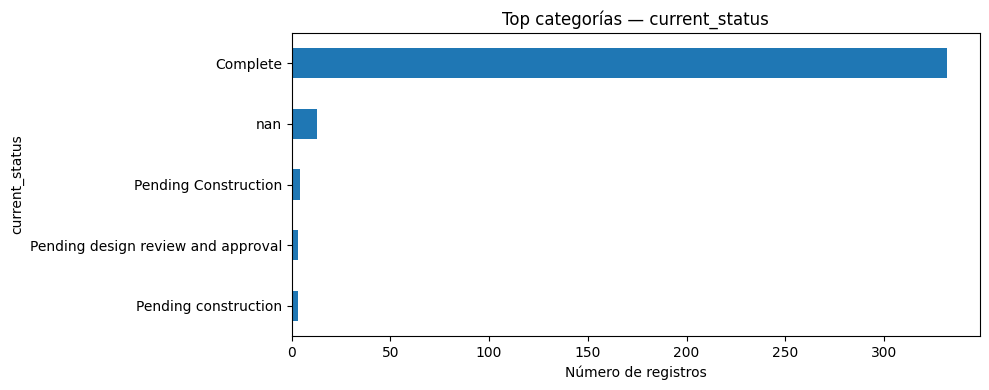

### Distribución de `tc_measure`

,tc_measure,count,pct
0,Raised Crosswalk,168,47.32
1,Traffic Island,85,23.94
2,Traffic Circle,35,9.86
3,Centerline Hardening w/Rubber Humps,13,3.66
4,Speed Hump,9,2.54
5,Speed Table,9,2.54
6,Left Turn Traffic Calming,8,2.25
7,Ped Refuge Island,7,1.97
8,Median Extension,6,1.69
9,Channelization,5,1.41


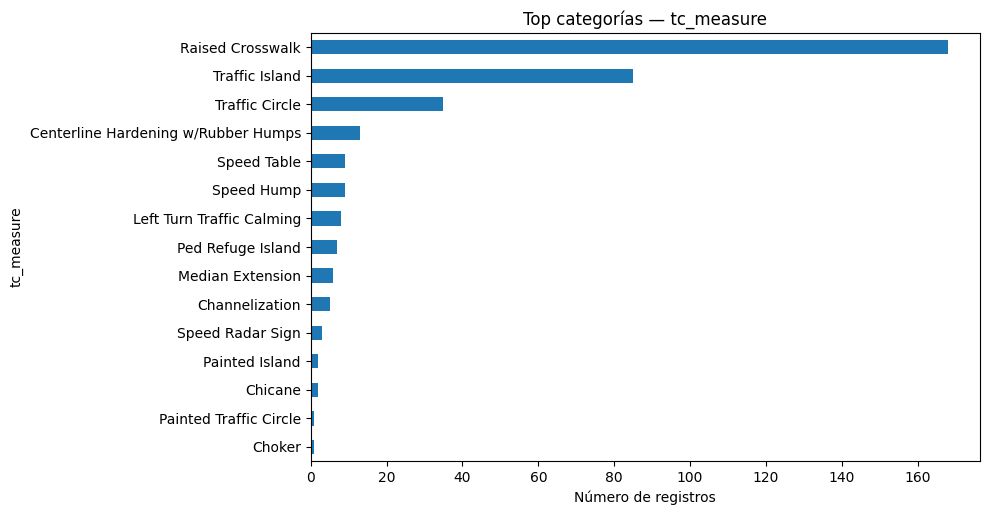

### Distribución de `program`

,program,count,pct
0,NaN,164,46.20
1,Site Specific,26,7.32
2,TC Implementation,25,7.04
3,Areawide,24,6.76
4,App-Based,13,3.66
5,FY25 D11 NTIP Sideshow Deterrence,13,3.66
6,Left Turn Traffic Calming,8,2.25
7,D11 NTIP,8,2.25
8,Corridor,7,1.97
9,Euclid TC,7,1.97


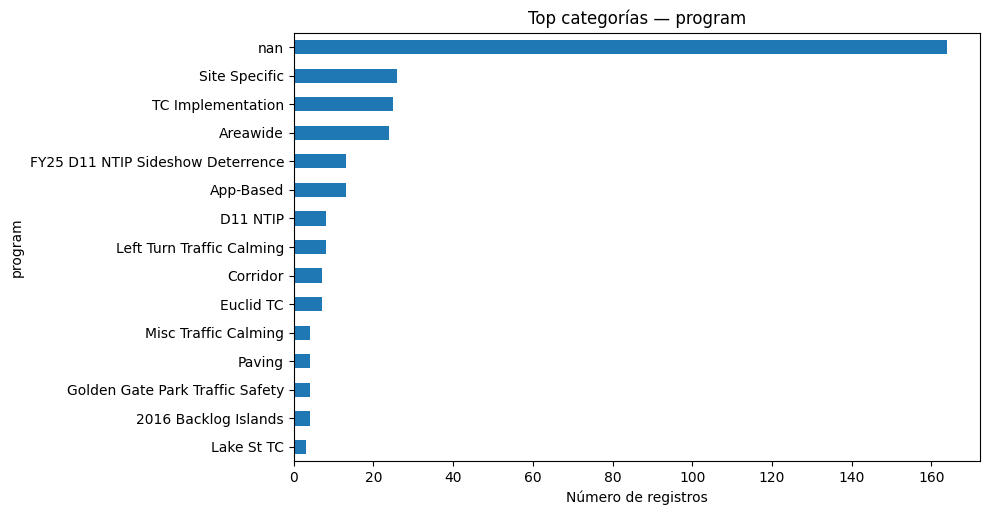

### Distribución de `fiscal_yr`

,fiscal_yr,count,pct
0,NaN,209,58.87
1,FY 2011-2012,23,6.48
2,FY 2008-2009,23,6.48
3,FY 2004-2005,20,5.63
4,FY 2013-2014,17,4.79
5,FY 2024-2025,13,3.66
6,FY 2009-2010,8,2.25
7,FY 2019-2020,7,1.97
8,FY 2005-2006,5,1.41
9,FY 2017-2018,5,1.41


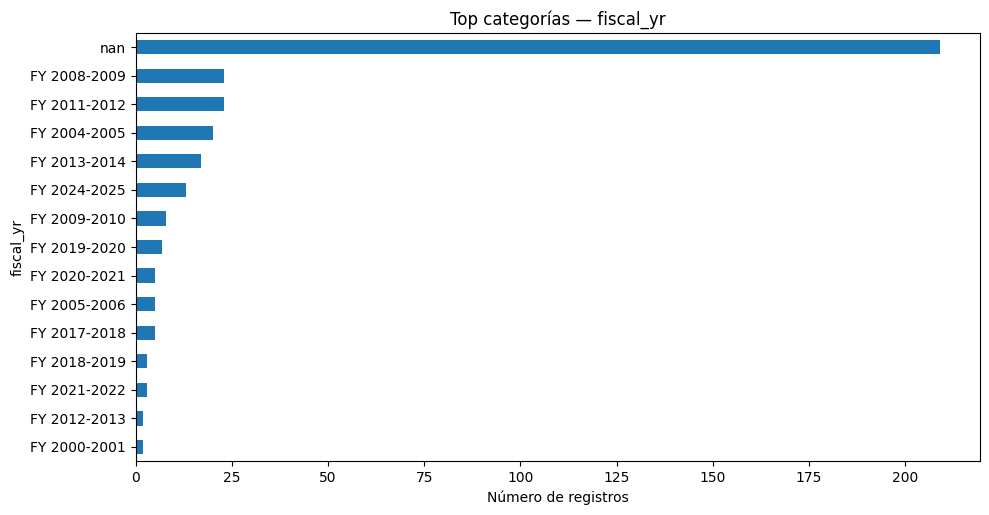

### Distribución de `supervisor_district`

,supervisor_district,count,pct
0,7.0,56,15.77
1,3.0,49,13.80
2,10.0,40,11.27
3,6.0,40,11.27
4,1.0,28,7.89
5,9.0,27,7.61
6,NaN,26,7.32
7,4.0,25,7.04
8,8.0,24,6.76
9,2.0,23,6.48


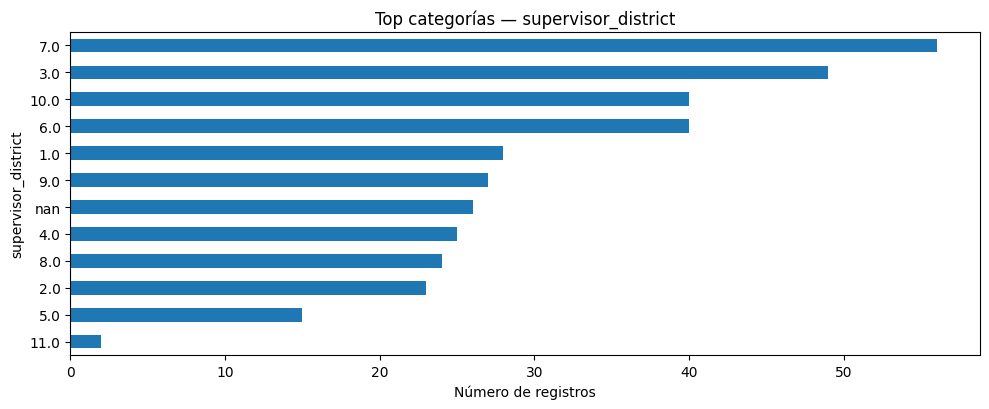

### Distribución de `analysis_neighborhood`

,analysis_neighborhood,count,pct
0,NaN,68,19.15
1,South of Market,25,7.04
2,Outer Sunset,20,5.63
3,Mission,15,4.23
4,Inner Richmond,12,3.38
5,Nob Hill,12,3.38
6,Parkmerced,11,3.10
7,Laurel Heights / Jordan Park,10,2.82
8,Bayview,10,2.82
9,Lower Nob Hill,10,2.82


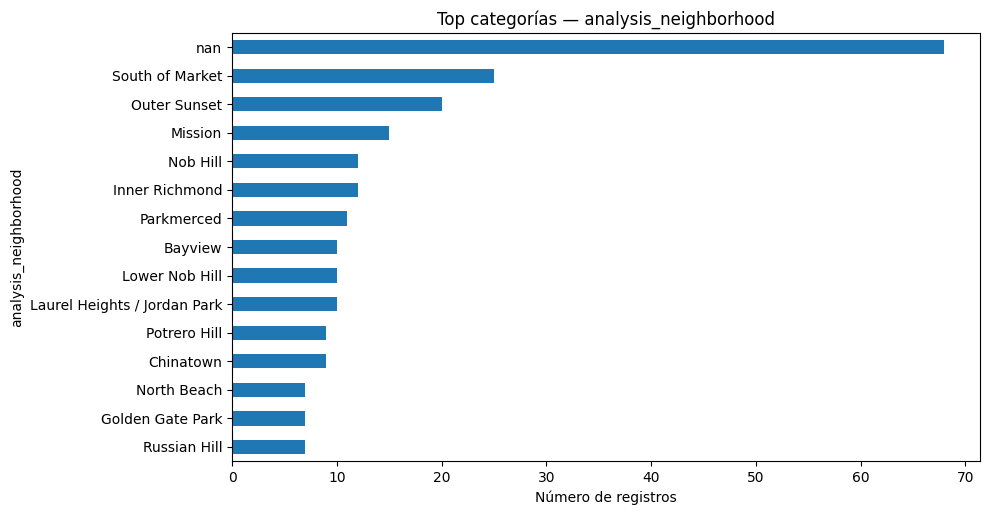

In [5]:

for col in ["current_status", "tc_measure", "program", "fiscal_yr", "supervisor_district", "analysis_neighborhood"]:
    if col in intersection.columns:
        display(Markdown(f"### Distribución de `{col}`"))
        display(top_values(intersection, col, n=20))
        barh_value_counts(intersection, col, title=f"Top categorías — {col}", n=15)


## 4. Variables temporales

,min_install_dt_clean,max_install_dt_clean,known_install_dates,unknown_install_dates
0,1957-01-01,2025-08-01,148,207


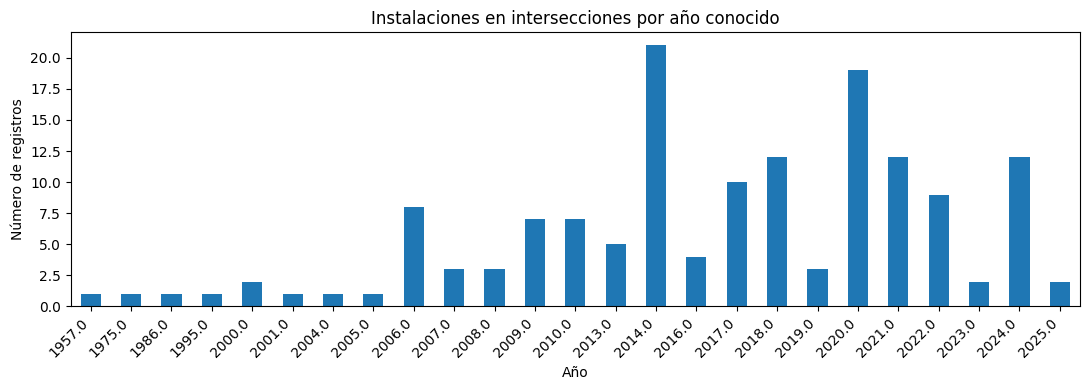

,install_year_clean,current_status,count
0,1957.0,Complete,1
1,1975.0,Complete,1
2,1986.0,Complete,1
3,1995.0,Complete,1
4,2000.0,Complete,2
5,2001.0,Complete,1
6,2004.0,Complete,1
7,2005.0,Complete,1
8,2006.0,Complete,8
9,2007.0,Complete,3


In [6]:

intersection["install_year_clean"] = intersection["install_dt_clean"].dt.year

display(pd.DataFrame({
    "min_install_dt_clean": [intersection["install_dt_clean"].min()],
    "max_install_dt_clean": [intersection["install_dt_clean"].max()],
    "known_install_dates": [intersection["install_dt_clean"].notna().sum()],
    "unknown_install_dates": [intersection["install_dt_clean"].isna().sum()],
}))

plot_year_counts(intersection.dropna(subset=["install_year_clean"]), "install_year_clean", "Instalaciones en intersecciones por año conocido")

yearly_status = (intersection.dropna(subset=["install_year_clean"])
                 .groupby(["install_year_clean", "current_status"], dropna=False)
                 .size()
                 .reset_index(name="count")
                 .sort_values(["install_year_clean", "count"], ascending=[True, False]))
display(yearly_status.head(40))


## 5. Revisión geográfica básica

`shape` contiene geometrías `POINT`, por lo que este dataset representa localizaciones puntuales de intersección.

,valid_geometries,missing_or_invalid_geometries,min_lon,max_lon,min_lat,max_lat
0,355,0,-122.509622,-122.373158,37.708867,37.806499


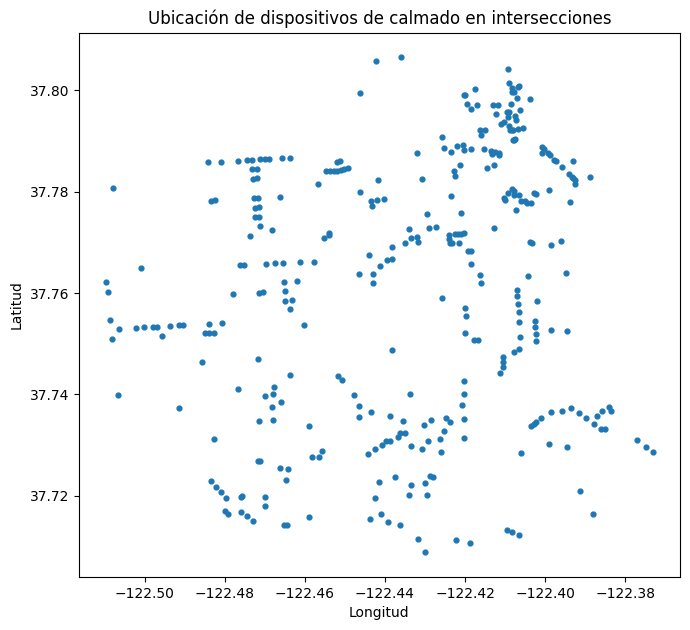

In [7]:

try:
    import geopandas as gpd
    from shapely import wkt

    def parse_wkt_safe(x):
        if pd.isna(x):
            return None
        try:
            return wkt.loads(x)
        except Exception:
            return None

    intersection_geo = intersection.copy()
    intersection_geo["geometry"] = intersection_geo["shape"].apply(parse_wkt_safe)
    intersection_gdf = gpd.GeoDataFrame(intersection_geo, geometry="geometry", crs="EPSG:4326")
    valid_points = intersection_gdf[intersection_gdf.geometry.notna()].copy()

    display(pd.DataFrame({
        "valid_geometries": [len(valid_points)],
        "missing_or_invalid_geometries": [intersection_gdf.geometry.isna().sum()],
        "min_lon": [valid_points.geometry.x.min()],
        "max_lon": [valid_points.geometry.x.max()],
        "min_lat": [valid_points.geometry.y.min()],
        "max_lat": [valid_points.geometry.y.max()],
    }))

    fig, ax = plt.subplots(figsize=(7, 7))
    valid_points.plot(ax=ax, markersize=12)
    ax.set_title("Ubicación de dispositivos de calmado en intersecciones")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("No se pudo ejecutar la parte geoespacial opcional:", repr(e))


## 6. Investigación de unión con los otros datasets

- `intersection.cnn` ↔ `injury.cnn_intrsctn_fkey`: unión principal por intersección.
- `intersection.cnn` **no** debería cruzarse con `injury.cnn_sgmt_fkey`: esa clave es de segmento.
- `intersection.cnn` puede coincidir parcialmente con `pci.CNN`, pero PCI está conceptualmente más orientado a segmentos de pavimento; conviene validar caso por caso o usar spatial join con segmentos PCI cercanos.
- Fatalidades no tienen `CNN` directo; se puede recuperar vía `fatality.case_id_fkey = injury.case_id_pkey` o mediante spatial join.

In [8]:

join_reports_intersection = pd.DataFrame([
    key_match_report(intersection, "cnn", injury, "cnn_intrsctn_fkey", "intersection", "injury"),
    key_match_report(intersection, "cnn", injury, "cnn_sgmt_fkey", "intersection", "injury"),
    key_match_report(intersection, "cnn", pci, "CNN", "intersection", "pci"),
    key_match_report(injury, "cnn_intrsctn_fkey", intersection, "cnn", "injury", "intersection"),
    key_match_report(injury, "cnn_sgmt_fkey", intersection, "cnn", "injury", "intersection"),
])
display(join_reports_intersection)


,left,right,left_non_null_rows,left_unique_keys,right_non_null_rows,right_unique_keys,matched_left_rows,matched_left_rows_pct,matched_left_unique_keys,matched_left_unique_keys_pct
0,intersection.cnn,injury.cnn_intrsctn_fkey,336,336,64657,6200,296,88.10,296,88.10
1,intersection.cnn,injury.cnn_sgmt_fkey,336,336,28914,7547,0,0.00,0,0.00
2,intersection.cnn,pci.CNN,336,336,307133,18349,217,64.58,217,64.58
3,injury.cnn_intrsctn_fkey,intersection.cnn,64657,6200,336,336,2274,3.52,296,4.77
4,injury.cnn_sgmt_fkey,intersection.cnn,28914,7547,336,336,0,0.00,0,0.00


## 7. Unión con accidentes/Injury

Primero se agregan los dispositivos por `cnn` de intersección y luego se unen a accidentes usando `cnn_intrsctn_fkey`.

In [9]:

intersection_features = (intersection
    .dropna(subset=["cnn_key"])
    .assign(
        is_complete=lambda d: d["current_status"].str.lower().eq("complete"),
        has_known_install_date=lambda d: d["install_dt_clean"].notna(),
    )
    .groupby("cnn_key")
    .agg(
        intersection_rows=("row_id", "count"),
        intersection_measure_types=("tc_measure", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
        intersection_n_measure_types=("tc_measure", lambda s: s.dropna().nunique()),
        intersection_units_total=("units", lambda s: pd.to_numeric(s, errors="coerce").sum(min_count=1)),
        intersection_first_install_dt=("install_dt_clean", "min"),
        intersection_last_install_dt=("install_dt_clean", "max"),
        intersection_complete_rows=("is_complete", "sum"),
        intersection_has_complete=("is_complete", "max"),
        intersection_statuses=("current_status", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
        intersection_neighborhoods=("analysis_neighborhood", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
    )
    .reset_index()
)

display(intersection_features.head())
print(f"Intersecciones con features: {len(intersection_features):,}")

injury_intersection = injury.merge(
    intersection_features,
    left_on="cnn_intrsctn_key",
    right_on="cnn_key",
    how="left",
    suffixes=("", "_intersection")
)

injury_intersection["has_intersection_calming"] = injury_intersection["intersection_rows"].notna()
injury_intersection["has_intersection_calming_before_crash"] = (
    injury_intersection["has_intersection_calming"]
    & injury_intersection["intersection_first_install_dt"].notna()
    & injury_intersection["collision_dt"].notna()
    & (injury_intersection["intersection_first_install_dt"] <= injury_intersection["collision_dt"])
)

summary_injury_intersection = pd.DataFrame({
    "metric": [
        "injury_rows_total",
        "injury_rows_with_intersection_key",
        "injury_rows_on_calmed_intersection",
        "injury_rows_on_calmed_intersection_pct_total",
        "injury_rows_with_intersection_calming_installed_before_crash",
        "unique_injury_intersections",
        "unique_injury_intersections_with_calming"
    ],
    "value": [
        len(injury_intersection),
        injury_intersection["cnn_intrsctn_key"].notna().sum(),
        injury_intersection["has_intersection_calming"].sum(),
        round(injury_intersection["has_intersection_calming"].mean() * 100, 2),
        injury_intersection["has_intersection_calming_before_crash"].sum(),
        injury_intersection["cnn_intrsctn_key"].nunique(dropna=True),
        injury_intersection.loc[injury_intersection["has_intersection_calming"], "cnn_intrsctn_key"].nunique(dropna=True),
    ]
})
display(summary_injury_intersection)

display(injury_intersection[[
    "unique_id", "case_id_pkey", "collision_dt", "cnn_intrsctn_fkey", "primary_rd", "secondary_rd",
    "intersection", "collision_severity", "number_injured", "number_killed",
    "has_intersection_calming", "has_intersection_calming_before_crash",
    "intersection_measure_types", "intersection_first_install_dt", "intersection_statuses"
]].head(20))


,cnn_key,intersection_rows,intersection_measure_types,intersection_n_measure_types,intersection_units_total,intersection_first_install_dt,intersection_last_install_dt,intersection_complete_rows,intersection_has_complete,intersection_statuses,intersection_neighborhoods
0,20011000,1,[Painted Traffic Circle],1,1.0,NaT,NaT,1,True,[Complete],[]
1,20046000,1,[Choker],1,1.0,2008-06-01,2008-06-01,1,True,[Complete],[Hunters Point]
2,20060000,1,[Channelization],1,1.0,NaT,NaT,1,True,[Complete],[Hunters Point]
3,20193000,1,[Raised Crosswalk],1,1.0,2017-10-01,2017-10-01,1,True,[Complete],[Bayview]
4,20196000,1,[Traffic Circle],1,1.0,2006-05-01,2006-05-01,1,True,[Complete],[Bayview]


Intersecciones con features: 336


,metric,value
0,injury_rows_total,64694.00
1,injury_rows_with_intersection_key,64657.00
2,injury_rows_on_calmed_intersection,2274.00
3,injury_rows_on_calmed_intersection_pct_total,3.52
4,injury_rows_with_intersection_calming_installe...,411.00
5,unique_injury_intersections,6200.00
6,unique_injury_intersections_with_calming,296.00


,unique_id,case_id_pkey,collision_dt,cnn_intrsctn_fkey,primary_rd,secondary_rd,intersection,collision_severity,number_injured,number_killed,has_intersection_calming,has_intersection_calming_before_crash,intersection_measure_types,intersection_first_install_dt,intersection_statuses
0,50327,190826792,2019-11-01 12:57:00,26037000.0,FELL ST,FILLMORE ST,Intersection <= 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
1,127581,240768967,2024-11-06 14:38:00,30731000.0,MARKET ST,01ST ST,Intersection <= 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
2,126576,250101272,2025-02-13 06:45:00,25186000.0,EDDY ST,VAN NESS AVE,Intersection <= 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
3,17417,5130580,2011-03-27 12:45:00,24378000.0,14TH ST,VALENCIA ST,Midblock > 20ft,Injury (Complaint of Pain),1,0.0,False,False,NaN,NaT,NaN
4,18653,4279173,2009-06-18 10:10:00,30749000.0,MARKET ST,12TH ST,Midblock > 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
5,20814,4788458,2010-06-05 14:13:00,25917000.0,GOUGH ST,LINDEN ST,Intersection <= 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
6,45379,140242405,2014-03-22 13:27:00,32859000.0,UNABLE TO GEOCODE,NaN,Midblock > 20ft,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
7,106122,180719602,2018-09-22 14:48:00,25276000.0,HYDE ST,JACKSON ST,Midblock > 20ft,Injury (Complaint of Pain),1,0.0,False,False,NaN,NaT,NaN
8,82519,230199899,2023-03-21 15:53:00,33540000.0,LAKE MERCED BLVD,BROTHERHOOD WAY,Midblock > 20ft,Injury (Severe),1,0.0,False,False,NaN,NaT,NaN
9,40212,3314387,2007-07-30 06:24:00,27399000.0,NORIEGA ST,28TH AVE,Intersection <= 20ft,Fatal,0,1.0,False,False,NaN,NaT,NaN


## 8. Relación con PCI histórico

PCI mide condición de pavimento. Aunque hay coincidencias de `CNN`, para intersecciones el cruce conceptual es más delicado que para mid-block. Recomendable usar PCI como feature del segmento asociado al accidente (`cnn_sgmt_fkey`) y usar este dataset como feature de intersección (`cnn_intrsctn_fkey`).

In [ ]:

intersection_pci_static = intersection_features.merge(
    pci[["cnn_key", "PCI_Score", "pci_change_dt", "Functional_Class"]],
    on="cnn_key",
    how="left"
)

display(pd.DataFrame({
    "intersection_unique_keys": [intersection_features["cnn_key"].nunique()],
    "intersection_keys_with_any_pci_same_cnn": [intersection_pci_static.groupby("cnn_key")["PCI_Score"].apply(lambda s: s.notna().any()).sum()],
    "pci_rows_after_static_join": [len(intersection_pci_static)],
}))

pci_latest = (pci.dropna(subset=["cnn_key", "pci_change_dt"])
              .sort_values(["cnn_key", "pci_change_dt"])
              .groupby("cnn_key", as_index=False)
              .tail(1)[["cnn_key", "PCI_Score", "pci_change_dt", "Functional_Class"]]
              .rename(columns={
                  "PCI_Score": "latest_segment_pci_score",
                  "pci_change_dt": "latest_segment_pci_change_dt",
                  "Functional_Class": "latest_segment_functional_class"
              }))

injury_with_intersection_and_latest_segment_pci = injury_intersection.merge(
    pci_latest,
    left_on="cnn_sgmt_key",
    right_on="cnn_key",
    how="left",
    suffixes=("", "_segment_pci")
)

display(injury_with_intersection_and_latest_segment_pci[[
    "unique_id", "collision_dt", "cnn_intrsctn_fkey", "cnn_sgmt_fkey",
    "has_intersection_calming", "intersection_measure_types",
    "latest_segment_pci_score", "latest_segment_pci_change_dt", "latest_segment_functional_class"
]].head(20))


,intersection_unique_keys,intersection_keys_with_any_pci_same_cnn,pci_rows_after_static_join
0,336,217,473


,unique_id,collision_dt,cnn_intrsctn_fkey,cnn_sgmt_fkey,has_intersection_calming,intersection_measure_types,latest_segment_pci_score,latest_segment_pci_change_dt,latest_segment_functional_class
0,50327,2019-11-01 12:57:00,26037000.0,NaN,False,NaN,NaN,NaT,NaN
1,127581,2024-11-06 14:38:00,30731000.0,NaN,False,NaN,NaN,NaT,NaN
2,126576,2025-02-13 06:45:00,25186000.0,NaN,False,NaN,NaN,NaT,NaN
3,17417,2011-03-27 12:45:00,24378000.0,588000.0,False,NaN,74.0,2025-09-15 08:45:43,Arterial
4,18653,2009-06-18 10:10:00,30749000.0,8756101.0,False,NaN,60.0,2025-08-17 08:22:14,Arterial
5,20814,2010-06-05 14:13:00,25917000.0,6317000.0,False,NaN,87.0,2025-08-17 08:21:44,Arterial
6,45379,2014-03-22 13:27:00,32859000.0,184101.0,False,NaN,78.0,2025-08-17 08:20:10,Arterial
7,106122,2018-09-22 14:48:00,25276000.0,7131000.0,False,NaN,58.0,2025-08-17 08:21:58,Collector
8,82519,2023-03-21 15:53:00,33540000.0,8052101.0,False,NaN,62.0,2025-09-01 09:12:23,Arterial
9,40212,2007-07-30 06:24:00,27399000.0,9661000.0,False,NaN,78.0,2025-09-01 09:12:50,Arterial


## 9. Fatalidades: unión indirecta o espacial

Para fatalidades, la ruta directa es recuperar `cnn_intrsctn_fkey` desde lesiones usando `case_id`. Los casos no recuperados pueden resolverse por spatial join entre el punto de fatalidad y el punto/intersección o segmento vial más cercano.

In [11]:

fatality_via_injury = fatality.merge(
    injury[["case_id_key", "cnn_sgmt_key", "cnn_intrsctn_key", "collision_dt", "primary_rd", "secondary_rd"]],
    left_on="case_id_key",
    right_on="case_id_key",
    how="left",
    suffixes=("_fatality", "_injury")
)

fatality_via_intersection = fatality_via_injury.merge(
    intersection_features,
    left_on="cnn_intrsctn_key",
    right_on="cnn_key",
    how="left"
)

summary_fatal_intersection = pd.DataFrame({
    "metric": [
        "fatality_rows_total",
        "fatality_rows_matched_to_injury_case",
        "fatality_rows_with_intersection_recovered",
        "fatality_rows_on_calmed_intersection",
        "fatality_rows_with_intersection_calming_before_crash"
    ],
    "value": [
        len(fatality_via_intersection),
        fatality_via_intersection["cnn_intrsctn_key"].notna().sum(),
        fatality_via_intersection["cnn_intrsctn_key"].notna().sum(),
        fatality_via_intersection["intersection_rows"].notna().sum(),
        (
            fatality_via_intersection["intersection_rows"].notna()
            & fatality_via_intersection["intersection_first_install_dt"].notna()
            & fatality_via_intersection["collision_dt_fatality"].notna()
            & (fatality_via_intersection["intersection_first_install_dt"] <= fatality_via_intersection["collision_dt_fatality"])
        ).sum() if "collision_dt_fatality" in fatality_via_intersection.columns else np.nan
    ]
})
display(summary_fatal_intersection)

display(fatality_via_intersection[[
    "unique_id", "case_id_key", "collision_dt_fatality", "cnn_sgmt_key", "cnn_intrsctn_key",
    "location", "deceased", "collision_type", "intersection_rows", "intersection_measure_types",
    "intersection_first_install_dt"
]].head(20))


,metric,value
0,fatality_rows_total,377
1,fatality_rows_matched_to_injury_case,353
2,fatality_rows_with_intersection_recovered,353
3,fatality_rows_on_calmed_intersection,10
4,fatality_rows_with_intersection_calming_before...,2


,unique_id,case_id_key,collision_dt_fatality,cnn_sgmt_key,cnn_intrsctn_key,location,deceased,collision_type,intersection_rows,intersection_measure_types,intersection_first_install_dt
0,1,140236301,2014-03-20 00:00:00,<NA>,20308000,Bayshore Blvd near Visitation Ave,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
1,2,140755533,2014-09-08 05:10:00,<NA>,20489000,3rd St at Carrol Ave,Pedestrian,Pedestrian vs LRV,NaN,NaN,NaT
2,4,140365546,2014-05-03 02:24:00,<NA>,21177000,Folsom St and Caesar Chavez,Driver,Motor Vehicle Collision,NaN,NaN,NaT
3,16,150562049,2015-06-28 03:52:00,<NA>,24450000,Van Ness Ave and Hayes St,Motorcyclist,Motorcycle vs Motor Vehicle,NaN,NaN,NaT
4,17,140104811,2014-02-05 02:26:00,<NA>,24459000,Van Ness Ave and Grove St,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
5,20240304,240137782,2024-03-02 00:28:00,6262000,24431000,Golden Gate Ave between Larkin and Hyde Sts,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
6,20241252,240627965,2024-10-06 01:11:00,14207000,34021000,Treasure Island Rd between Clipper Cove Way an...,Driver,Motor Vehicle Collision (solo),NaN,NaN,NaT
7,20240391,240169569,2024-03-16 12:13:00,12786000,22963000,Ulloa St and Lenox Way,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
8,20240644,240280228,2024-05-03 23:32:00,<NA>,20573000,Mansell St and San Bruno Ave,Passenger,Motor Vehicle Collision,NaN,NaN,NaT
9,20240932,240417841,2024-07-05 01:14:00,<NA>,24142000,16th St and South Van Ness Ave,Motorcyclist,Motorcycle vs Motor Vehicle,NaN,NaN,NaT


## 10. Integración conjunta con mid-block

En una tabla de accidentes, un mismo registro puede tener dos tipos de exposición:

- Features de segmento: `cnn_sgmt_fkey` → mid-block + PCI.
- Features de intersección: `cnn_intrsctn_fkey` → dispositivos de intersección.

Esto permite modelar efectos separados: condición del pavimento del segmento, medidas instaladas en el tramo, y medidas instaladas en la intersección.

In [12]:

# Features mid-block agregadas, para combinar con features de intersección en accidentes.
mid_features = (mid
    .dropna(subset=["cnn_key"])
    .assign(is_complete=lambda d: d["current_status"].str.lower().eq("complete"))
    .groupby("cnn_key")
    .agg(
        midblock_rows=("row_id", "count"),
        midblock_measure_types=("tc_measure", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
        midblock_first_install_dt=("install_dt_clean", "min"),
        midblock_has_complete=("is_complete", "max"),
    )
    .reset_index()
)

injury_joint = (injury
    .merge(mid_features, left_on="cnn_sgmt_key", right_on="cnn_key", how="left")
    .merge(intersection_features, left_on="cnn_intrsctn_key", right_on="cnn_key", how="left", suffixes=("_midkey", "_intersectionkey"))
)

injury_joint["has_midblock_calming"] = injury_joint["midblock_rows"].notna()
injury_joint["has_intersection_calming"] = injury_joint["intersection_rows"].notna()

joint_summary = pd.DataFrame({
    "group": [
        "no calming match",
        "mid-block only",
        "intersection only",
        "both mid-block and intersection"
    ],
    "injury_rows": [
        ((~injury_joint["has_midblock_calming"]) & (~injury_joint["has_intersection_calming"])).sum(),
        ((injury_joint["has_midblock_calming"]) & (~injury_joint["has_intersection_calming"])).sum(),
        ((~injury_joint["has_midblock_calming"]) & (injury_joint["has_intersection_calming"])).sum(),
        ((injury_joint["has_midblock_calming"]) & (injury_joint["has_intersection_calming"])).sum(),
    ]
})
joint_summary["pct"] = (joint_summary["injury_rows"] / len(injury_joint) * 100).round(2)
display(joint_summary)

display(injury_joint[[
    "unique_id", "collision_dt", "cnn_sgmt_fkey", "cnn_intrsctn_fkey",
    "has_midblock_calming", "midblock_measure_types",
    "has_intersection_calming", "intersection_measure_types",
    "collision_severity", "number_injured", "number_killed"
]].head(20))


,group,injury_rows,pct
0,no calming match,60529,93.56
1,mid-block only,1891,2.92
2,intersection only,2119,3.28
3,both mid-block and intersection,155,0.24


,unique_id,collision_dt,cnn_sgmt_fkey,cnn_intrsctn_fkey,has_midblock_calming,midblock_measure_types,has_intersection_calming,intersection_measure_types,collision_severity,number_injured,number_killed
0,50327,2019-11-01 12:57:00,NaN,26037000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
1,127581,2024-11-06 14:38:00,NaN,30731000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
2,126576,2025-02-13 06:45:00,NaN,25186000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
3,17417,2011-03-27 12:45:00,588000.0,24378000.0,False,NaN,False,NaN,Injury (Complaint of Pain),1,0.0
4,18653,2009-06-18 10:10:00,8756101.0,30749000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
5,20814,2010-06-05 14:13:00,6317000.0,25917000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
6,45379,2014-03-22 13:27:00,184101.0,32859000.0,False,NaN,False,NaN,Injury (Other Visible),1,0.0
7,106122,2018-09-22 14:48:00,7131000.0,25276000.0,False,NaN,False,NaN,Injury (Complaint of Pain),1,0.0
8,82519,2023-03-21 15:53:00,8052101.0,33540000.0,False,NaN,False,NaN,Injury (Severe),1,0.0
9,40212,2007-07-30 06:24:00,9661000.0,27399000.0,False,NaN,False,NaN,Fatal,0,1.0


## 11. Dataset analítico para IA

Para riesgo vial, la granularidad recomendada es **segmento/intersección + periodo temporal**. Si se modelan intersecciones, la unidad puede ser `cnn_intrsctn_fkey + año/mes`; si se modelan segmentos, la unidad puede ser `cnn_sgmt_fkey + año/mes`.

Variables candidatas desde este dataset:

- `intersection_has_complete`
- `intersection_n_measure_types`
- `intersection_units_total`
- `intersection_first_install_dt` / antigüedad de la intervención
- tipo de dispositivo: raised crosswalk, traffic island, traffic circle, etc.

Variables conjuntas recomendadas:

- PCI vigente del segmento asociado
- features mid-block del segmento asociado
- features de intersección
- histórico de accidentes por ubicación y periodo
- target futuro de accidentes o severidad ponderada

In [13]:

intersection_feature_table = intersection_features.copy()
intersection_feature_table["has_known_install_date"] = intersection_feature_table["intersection_first_install_dt"].notna()

display(intersection_feature_table.head(20))

output_path = Path("intersection_calming_features_preview.csv")
intersection_feature_table.to_csv(output_path, index=False)
print(f"Feature table exportada a: {output_path.resolve()}")


,cnn_key,intersection_rows,intersection_measure_types,intersection_n_measure_types,intersection_units_total,intersection_first_install_dt,intersection_last_install_dt,intersection_complete_rows,intersection_has_complete,intersection_statuses,intersection_neighborhoods,has_known_install_date
0,20011000,1,[Painted Traffic Circle],1,1.0,NaT,NaT,1,True,[Complete],[],False
1,20046000,1,[Choker],1,1.0,2008-06-01,2008-06-01,1,True,[Complete],[Hunters Point],True
2,20060000,1,[Channelization],1,1.0,NaT,NaT,1,True,[Complete],[Hunters Point],False
3,20193000,1,[Raised Crosswalk],1,1.0,2017-10-01,2017-10-01,1,True,[Complete],[Bayview],True
4,20196000,1,[Traffic Circle],1,1.0,2006-05-01,2006-05-01,1,True,[Complete],[Bayview],True
5,20197000,1,[Speed Table],1,1.0,2024-09-01,2024-09-01,1,True,[Complete],[Bayview],True
6,20198000,1,[Traffic Circle],1,1.0,2006-06-01,2006-06-01,1,True,[Complete],[Bayview],True
7,20200000,1,[Traffic Circle],1,1.0,2006-05-01,2006-05-01,1,True,[Complete],[Bayview],True
8,20201000,1,[Raised Crosswalk],1,1.0,2017-10-01,2017-10-01,1,True,[Complete],[Bayview],True
9,20208000,1,[Speed Table],1,1.0,2024-07-01,2024-07-01,1,True,[Complete],[Bayview],True


Feature table exportada a: C:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\eda_calming\intersection_calming_features_preview.csv


## 12. Conclusiones 

- La clave natural de este dataset es `cnn` a nivel de intersección.
- Para accidentes con lesiones, la unión principal es `intersection.cnn = injury.cnn_intrsctn_fkey`.
- No debe usarse `intersection.cnn = injury.cnn_sgmt_fkey`; en los datos no aparece como una relación válida.
- PCI debe añadirse preferentemente desde el segmento del accidente (`cnn_sgmt_fkey = PCI.CNN`), no necesariamente desde la intersección.
- Para fatalidades, usar `case_id` contra lesiones o spatial join.
- Para IA, separar features de segmento y features de intersección reduce errores conceptuales y mejora interpretabilidad.